# Estimação do Consumo de Combustível de Aeronaves por Regressão Linear e Polinomial

**Disciplina:** Data Science & Statistical Computing, CKP04

**Base de dados:** Dados Estatísticos do Transporte Aéreo, Agência Nacional de Aviação Civil (ANAC)

**Gabrielle Calazans - RM: 564460**

**Jéssica Domingues - RM: 562973**

**João Vitor Piccolo - RM: 565127**

**Kauã Carvalho de Oliveira - RM: 566371**

**Leonardo Pereira - RM: 561349**

---

Este notebook documenta, passo a passo, todo o processo de um projeto de regressão linear aplicado a dados reais. Ao final, o modelo escolhido é exportado para ser consumido por uma aplicação Streamlit.

## 1. Proposição do problema

### 1.1 Contexto

A ANAC (Agência Nacional de Aviação Civil) publica, desde o ano 2000, uma série histórica mensal com os principais indicadores operacionais de todas as empresas aéreas (brasileiras e estrangeiras) que operam no Brasil, desagregada por **par de aeroportos (origem-destino), empresa aérea, ano e mês**. Entre os indicadores está o volume de **combustível consumido (em litros)** em cada etapa de voo consolidada no mês.

### 1.2 Pergunta de pesquisa

> **Em que medida a distância voada, o número de decolagens (frequência de voos) e o volume de carga paga transportada explicam o total de combustível consumido (em litros) por uma empresa aérea, em um determinado par de aeroportos, ao longo de um mês, em voos regulares domésticos no Brasil?**

### 1.3 Variável resposta (y)

- **`COMBUSTIVEL_LITROS`**, volume total de combustível de aviação consumido pela empresa, naquele par origem-destino, naquele mês. Unidade: **litros (L)**. Variável quantitativa contínua.

### 1.4 Variáveis explicativas (X)

- **`DISTANCIA_VOADA_KM`** - Distância total voada no mês naquele par de aeroportos. Unidade: **Quilômetros (km)**.

- **`DECOLAGENS`** - Quantidade de voos (etapas) realizados no mês.

- **`CARGA_PAGA_KG`** - Carga paga transportada no mês. Unidade: **Quilos (kg)**.

- **`AEROPORTO_DE_ORIGEM_REGIAO`** - Região geográfica do aeroporto de origem

- **`HORAS_VOADAS`** - Tempo total de voo no mês. Unidade: **Horas**

| `PASSAGEIROS_PAGOS` | nº de passageiros | Passageiros pagantes transportados no mês |
| `ASSENTOS` | nº de assentos | Assentos oferecidos (capacidade) no mês |
| `PAYLOAD` | kg | Capacidade de carga útil ofertada (aeronave × decolagens) |


### 1.5 Justificativa da relevância

O consumo de combustível está diretamente ligado a três dimensões físicas de uma operação aérea: **quanta distância é percorrida**, **quantas vezes a aeronave decola e sobe até a altitude de cruzeiro** (a fase de decolagem/subida consome desproporcionalmente mais combustível que o cruzeiro) e **quanto peso está sendo transportado** (carga e passageiros aumentam o consumo). Um modelo de regressão que combine essas dimensões permite não apenas prever o consumo, mas também **interpretar a contribuição relativa de cada fator**, informação de grande valor prático para as próprias companhias aéreas e para reguladores.

### 1.6 Hipóteses iniciais

Antes de qualquer modelagem, o grupo registra as seguintes hipóteses, que serão retomadas na conclusão:

- **H1:** Existe uma relação positiva e aproximadamente proporcional entre `DISTANCIA_VOADA_KM` e `COMBUSTIVEL_LITROS`, quanto mais distância voada no mês, mais combustível consumido.
- **H2:** O número de `DECOLAGENS` tem um efeito positivo sobre o consumo **mesmo controlando pela distância**, pois cada decolagem/pouso consome um "custo fixo" adicional de combustível (fase de subida é mais intensiva que o cruzeiro).
- **H3:** O volume de carga paga (`CARGA_PAGA_KG`) tem um efeito positivo, porém pequeno em magnitude relativa, sobre o consumo (peso adicional aumenta o arrasto/consumo, mas seu efeito é marginal comparado à distância percorrida).

Não se afirma causalidade entre as variáveis explicativas e o combustível consumido, trata-se de uma relação de **associação estatística**, ainda que apoiada por uma justificativa física plausível (queima de combustível é uma consequência mecânica direta de distância, decolagens e peso transportado).

## 2. Origem e documentação dos dados

- **Nome da base:** *Dados Estatísticos do Transporte Aéreo*
- **Fonte:** Agência Nacional de Aviação Civil (ANAC), Portal de Dados Abertos
- **Endereço de acesso:** https://www.anac.gov.br/acesso-a-informacao/dados-abertos/areas-de-atuacao/voos-e-operacoes-aereas/dados-estatisticos-do-transporte-aereo
- **Data de acesso:** 23/08/2026
- **Unidade de observação (linha) na base bruta:** combinação **empresa aérea × aeroporto de origem × aeroporto de destino × ano × mês**, ou seja, cada linha resume, para um mês específico, todas as etapas voadas por uma empresa naquele par de aeroportos.

### 2.1 Dicionário de dados (variáveis utilizadas neste projeto)

| **Variável** | **Tipo** | **Unidade / Categorias** | **Descrição** |
|:---|:---|:---|:---|
| `EMPRESA_SIGLA` | Categórica nominal | Código da empresa | Sigla que identifica a empresa aérea responsável pelo voo. |
| `ANO` | Numérica discreta | Ano | Ano de realização do voo. |
| `MES` | Numérica discreta | 1 a 12 | Mês de realização do voo. |
| `HORAS_VOADAS` | Numérica contínua | Horas | Quantidade de horas voadas pela aeronave. |

## 3. Importação das bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

import pickle
import json
import os

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("modelo", exist_ok=True)
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 4. Carregamento da Base
O arquivo bruto da ANAC é um CSV com separador `;`, codificação `utf-8`.

Para viabilizar o processamento, carregamos apenas as colunas relevantes para este projeto.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

COLUNAS_UTEIS = [
    "EMPRESA_SIGLA", "EMPRESA_NOME", "EMPRESA_NACIONALIDADE",
    "ANO", "MES",
    "AEROPORTO_DE_ORIGEM_SIGLA",
    "AEROPORTO_DE_ORIGEM_REGIAO",
    "AEROPORTO_DE_ORIGEM_PAIS",
    "AEROPORTO_DE_DESTINO_SIGLA",
    "AEROPORTO_DE_DESTINO_PAIS",
    "NATUREZA", "GRUPO_DE_VOO",
    "PASSAGEIROS_PAGOS", "CARGA_PAGA_KG", "ASK", "RPK",
    "COMBUSTIVEL_LITROS", "DISTANCIA_VOADA_KM", "DECOLAGENS",
    "ASSENTOS", "PAYLOAD", "HORAS_VOADAS",
]

CAMINHO_BASE = "/content/drive/MyDrive/Colab Notebooks/Dados_Estatisticos.csv"

df_bruto = pd.read_csv(
    CAMINHO_BASE,
    sep=";",
    usecols=COLUNAS_UTEIS,
    encoding="utf-8-sig",
    dtype=str,
    skiprows=1,
)

print(
    f"Dimensões da base bruta: "
    f"{df_bruto.shape[0]:,} linhas x {df_bruto.shape[1]} colunas"
)

df_bruto.head()

Mounted at /content/drive
Dimensões da base bruta: 1,093,296 linhas x 22 colunas


,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,AEROPORTO_DE_DESTINO_SIGLA,AEROPORTO_DE_DESTINO_PAIS,...,PASSAGEIROS_PAGOS,CARGA_PAGA_KG,ASK,RPK,COMBUSTIVEL_LITROS,DISTANCIA_VOADA_KM,DECOLAGENS,ASSENTOS,PAYLOAD,HORAS_VOADAS
0,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,NaN,NaN,NaN,KMIA,ESTADOS UNIDOS DA AMÉRICA,...,152,2285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KDFW,NaN,ESTADOS UNIDOS DA AMÉRICA,SBGR,BRASIL,...,3932,97876,52184520,32415408,NaN,247320,30,6330,1050000,"409,08"
2,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,NaN,ESTADOS UNIDOS DA AMÉRICA,SBGL,BRASIL,...,2338,48066,47293751,18070402,NaN,224141,29,6119,464000,"418,1"
3,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,NaN,ESTADOS UNIDOS DA AMÉRICA,SBGR,BRASIL,...,2892,194997,46896016,22164288,NaN,222256,29,6119,1015000,"411,5"
4,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KMIA,NaN,ESTADOS UNIDOS DA AMÉRICA,SBCF,BRASIL,...,997,91022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_bruto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093296 entries, 0 to 1093295
Data columns (total 22 columns):
 #   Column                      Non-Null Count    Dtype 
---  ------                      --------------    ----- 
 0   EMPRESA_SIGLA               1093296 non-null  object
 1   EMPRESA_NOME                1093296 non-null  object
 2   EMPRESA_NACIONALIDADE       1093296 non-null  object
 3   ANO                         1093296 non-null  object
 4   MES                         1093296 non-null  object
 5   AEROPORTO_DE_ORIGEM_SIGLA   1088084 non-null  object
 6   AEROPORTO_DE_ORIGEM_REGIAO  927825 non-null   object
 7   AEROPORTO_DE_ORIGEM_PAIS    1088084 non-null  object
 8   AEROPORTO_DE_DESTINO_SIGLA  1093296 non-null  object
 9   AEROPORTO_DE_DESTINO_PAIS   1093296 non-null  object
 10  NATUREZA                    1093296 non-null  object
 11  GRUPO_DE_VOO                1093294 non-null  object
 12  PASSAGEIROS_PAGOS           1052954 non-null  object
 13  CARGA_PAGA_K

## 5. Preparação dos dados

A base bruta cobre **voos domésticos e internacionais, regulares e não regulares, de 2000 até o mês mais recente disponível**, para dezenas de empresas aéreas.

### 5.1 Registros duplicados

In [ ]:
n_duplicados = df_bruto.duplicated().sum()
print(f"Linhas duplicadas na base bruta: {n_duplicados}")

Linhas duplicadas na base bruta: 0


### 5.2 Definição do escopo do projeto

A base bruta mistura contextos operacionais muito diferentes (voo doméstico curto x voo internacional de longa distância; voo regular x fretamento x voo improdutivo/teste). Misturar esses contextos tornaria o modelo pouco interpretável e violaria a suposição de que os efeitos de distância/decolagens/carga sobre o combustível são razoavelmente homogêneos na amostra.

- **`NATUREZA == "DOMÉSTICA"`**, mantemos apenas voos domésticos.

- **`GRUPO_DE_VOO == "REGULAR"`**, mantemos apenas voos regulares (linhas aéreas comerciais programadas), excluindo fretamentos (`NÃO REGULAR`) e voos sem transporte comercial (`IMPRODUTIVO`), que têm dinâmica de consumo muito diferente.
- **`ANO` entre 2020 e 2025**, usamos os 5 anos mais recentes e **completos** (o ano de 2026 está disponível apenas até o mês de junho na data de acesso, portanto foi excluído para não distorcer comparações anuais).

In [ ]:
df = df_bruto[
    (df_bruto["NATUREZA"] == "DOMÉSTICA")
    & (df_bruto["GRUPO_DE_VOO"] == "REGULAR")
    & (df_bruto["ANO"].isin(["2020","2021", "2022", "2023", "2024", "2025"]))
].copy()

print(f"Linhas após filtro de escopo (doméstico, regular, 2021-2025): {len(df):,}")

Linhas após filtro de escopo (doméstico, regular, 2021-2025): 87,161


### 5.3 Conversão de tipos

Todas as colunas foram carregadas como texto (`dtype=str`) para preservar a formatação original.




In [ ]:
COLUNAS_NUMERICAS = [
    "PASSAGEIROS_PAGOS", "CARGA_PAGA_KG", "ASK", "RPK",
    "COMBUSTIVEL_LITROS", "DISTANCIA_VOADA_KM", "DECOLAGENS",
    "ASSENTOS", "PAYLOAD", "HORAS_VOADAS",
]

for col in COLUNAS_NUMERICAS:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

df[COLUNAS_NUMERICAS].dtypes

,0
PASSAGEIROS_PAGOS,float64
CARGA_PAGA_KG,float64
ASK,float64
RPK,float64
COMBUSTIVEL_LITROS,float64
DISTANCIA_VOADA_KM,float64
DECOLAGENS,float64
ASSENTOS,float64
PAYLOAD,float64
HORAS_VOADAS,float64


##5.4 Valores ausentes

In [ ]:
ausentes = df[COLUNAS_NUMERICAS].isna().sum().to_frame("qtd_ausentes")
ausentes["pct_ausentes"] = (ausentes["qtd_ausentes"] / len(df) * 100).round(2)
ausentes

,qtd_ausentes,pct_ausentes
PASSAGEIROS_PAGOS,376,0.43
CARGA_PAGA_KG,376,0.43
ASK,3431,3.94
RPK,3431,3.94
COMBUSTIVEL_LITROS,3429,3.93
DISTANCIA_VOADA_KM,3431,3.94
DECOLAGENS,3429,3.93
ASSENTOS,3429,3.93
PAYLOAD,3429,3.93
HORAS_VOADAS,3429,3.93


### 5.5 Valores impossíveis / incoerentes

Fisicamente, uma etapa de voo não pode ter distância voada igual a zero. Verificamos quantas linhas apresentam esse problema:

In [ ]:
n_dist_zero = (df["DISTANCIA_VOADA_KM"] == 0).sum()
print(f"Linhas com DISTANCIA_VOADA_KM == 0: {n_dist_zero}")
df.loc[df["DISTANCIA_VOADA_KM"] == 0, ["EMPRESA_SIGLA", "DECOLAGENS", "COMBUSTIVEL_LITROS", "HORAS_VOADAS"]].head()

Linhas com DISTANCIA_VOADA_KM == 0: 87


,EMPRESA_SIGLA,DECOLAGENS,COMBUSTIVEL_LITROS,HORAS_VOADAS
865013,ACN,1.00,366.00,2.00
865020,ACN,1.00,640.00,3.45
865071,ACN,2.00,556.00,3.03
865104,ACN,2.00,729.00,3.93
865262,ACN,1.00,693.00,3.57


São poucos casos, provavelmente erros de apuração/registro. Como é fisicamente incoerente e representa uma fração muito pequena da base, essas linhas serão removidas junto com os ausentes.

In [ ]:
shape_antes = df.shape

df_tratado = df.dropna(subset=COLUNAS_NUMERICAS).copy()
df_tratado = df_tratado[df_tratado["DISTANCIA_VOADA_KM"] > 0].copy()
df_tratado = df_tratado.reset_index(drop=True)

print("Comparação de dimensões:")
print(f"  Base bruta (2000-2026, todas as naturezas/grupos):      {df_bruto.shape}")
print(f"  Após filtro de escopo (doméstico/regular/2021-2025):    {shape_antes}")
print(f"  Após remoção de ausentes e distância zero (base final): {df_tratado.shape}")
print(f"  Total de linhas removidas nesta etapa: {shape_antes[0] - df_tratado.shape[0]:,} "
      f"({100*(shape_antes[0]-df_tratado.shape[0])/shape_antes[0]:.2f}% da base filtrada)")

Comparação de dimensões:
  Base bruta (2000-2026, todas as naturezas/grupos):      (1093296, 22)
  Após filtro de escopo (doméstico/regular/2021-2025):    (87161, 22)
  Após remoção de ausentes e distância zero (base final): (83267, 22)
  Total de linhas removidas nesta etapa: 3,894 (4.47% da base filtrada)


In [ ]:
output_dir = os.path.join(os.path.dirname(CAMINHO_BASE), "dados")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "base_tratada.csv")
df_tratado.to_csv(output_path, index=False)
print(f"Base tratada salva em {output_path} -> {df_tratado.shape[0]:,} linhas x {df_tratado.shape[1]} colunas")
df_tratado.head()

Base tratada salva em /content/drive/MyDrive/Colab Notebooks/dados/base_tratada.csv -> 83,267 linhas x 22 colunas


,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,AEROPORTO_DE_DESTINO_SIGLA,AEROPORTO_DE_DESTINO_PAIS,...,PASSAGEIROS_PAGOS,CARGA_PAGA_KG,ASK,RPK,COMBUSTIVEL_LITROS,DISTANCIA_VOADA_KM,DECOLAGENS,ASSENTOS,PAYLOAD,HORAS_VOADAS
0,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),BRASILEIRA,2020,1,SBBE,NORTE,BRASIL,SBMD,BRASIL,...,15.00,245.00,"49,896.00","6,930.00","3,692.00","5,544.00",12.00,108.00,"16,248.00",19.88
1,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),BRASILEIRA,2020,1,SBBG,SUL,BRASIL,SBPA,BRASIL,...,139.00,"1,178.00","78,003.00","44,619.00","6,487.00","8,667.00",27.00,243.00,"38,012.00",36.28
2,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),BRASILEIRA,2020,1,SBCA,SUL,BRASIL,SBCT,BRASIL,...,0.00,0.00,"3,951.00",0.00,350.00,439.00,1.00,9.00,"1,320.00",1.92
3,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),BRASILEIRA,2020,1,SBCT,SUL,BRASIL,SBCA,BRASIL,...,7.00,0.00,"3,951.00","3,073.00",500.00,439.00,1.00,9.00,"1,200.00",2.72
4,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),BRASILEIRA,2020,1,SBCT,SUL,BRASIL,SSCT,BRASIL,...,77.00,577.00,"51,156.00","31,262.00","4,495.00","5,684.00",14.00,126.00,"18,805.00",25.37


##6. EDA
### 6.1 Estatísticas descritivas da variável resposta



In [ ]:
df_tratado["COMBUSTIVEL_LITROS"].describe().to_frame("COMBUSTIVEL_LITROS (L)")

,COMBUSTIVEL_LITROS (L)
count,"83,267.00"
mean,"206,790.18"
std,"294,679.79"
min,3.00
25%,"21,944.00"
50%,"99,245.00"
75%,"270,607.00"
max,"3,020,792.00"


In [ ]:
print(f"Assimetria (skewness) de COMBUSTIVEL_LITROS: {df_tratado['COMBUSTIVEL_LITROS'].skew():.2f}")
print(f"Curtose: {df_tratado['COMBUSTIVEL_LITROS'].kurt():.2f}")

Assimetria (skewness) de COMBUSTIVEL_LITROS: 2.86
Curtose: 10.97


### 6.2 Distribuição da variável resposta

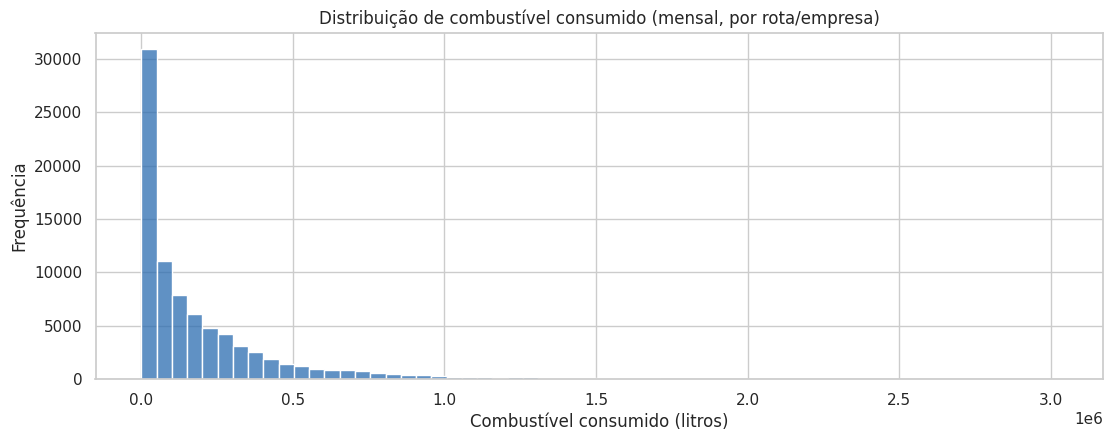

In [ ]:
fig, axes = plt.subplots(1, figsize=(13, 4.5))

sns.histplot(
    df_tratado["COMBUSTIVEL_LITROS"],
    bins=60,
    ax=axes,
    color="#2b6cb0"
)

axes.set_title("Distribuição de combustível consumido (mensal, por rota/empresa)")
axes.set_xlabel("Combustível consumido (litros)")
axes.set_ylabel("Frequência")

plt.show()

a distribuição é fortemente assimétrica à direita (skewness ≈ 2,8). Isso é esperado: a base mistura, na mesma coluna, rotas operadas por poucas decolagens de aeronaves pequenas (baixo consumo mensal) e rotas de alta frequência operadas pelas três maiores companhias do país (Azul, Gol, Latam), que somam dezenas de milhares de decolagens/mês em algumas rotas (consumo mensal na casa de milhões de litros).

### 6.3 Relação entre a resposta e as variáveis quantitativas

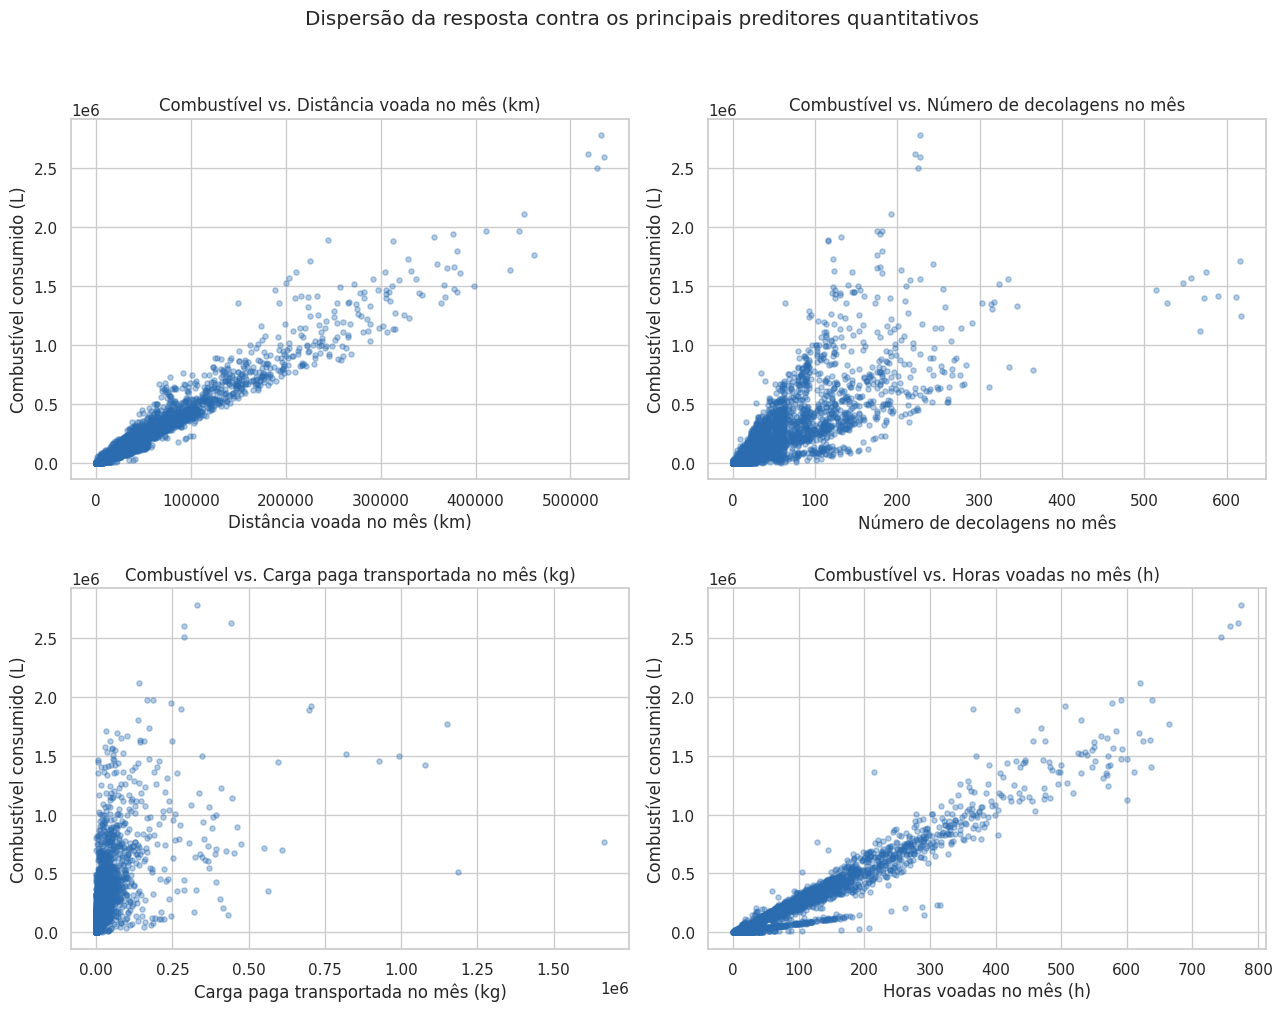

In [ ]:
amostra_plot = df_tratado.sample(4000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

pares = [
    ("DISTANCIA_VOADA_KM", "Distância voada no mês (km)"),
    ("DECOLAGENS", "Número de decolagens no mês"),
    ("CARGA_PAGA_KG", "Carga paga transportada no mês (kg)"),
    ("HORAS_VOADAS", "Horas voadas no mês (h)"),
]

for ax, (col, label) in zip(axes.ravel(), pares):
    ax.scatter(amostra_plot[col], amostra_plot["COMBUSTIVEL_LITROS"], alpha=0.35, s=14, color="#2b6cb0")
    ax.set_xlabel(label)
    ax.set_ylabel("Combustível consumido (L)")
    ax.set_title(f"Combustível vs. {label}")

plt.suptitle("Dispersão da resposta contra os principais preditores quantitativos\n", y=1.01)
plt.tight_layout()
plt.show()

###6.4 Matriz de correlação


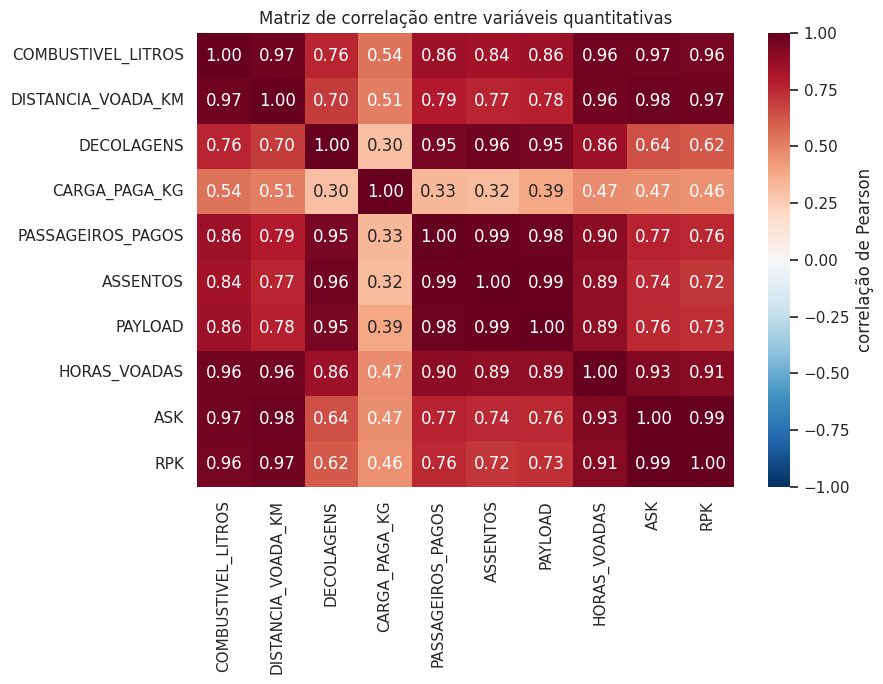

,COMBUSTIVEL_LITROS
COMBUSTIVEL_LITROS,1.00
DISTANCIA_VOADA_KM,0.97
ASK,0.97
HORAS_VOADAS,0.96
RPK,0.96
PASSAGEIROS_PAGOS,0.86
PAYLOAD,0.86
ASSENTOS,0.84
DECOLAGENS,0.76
CARGA_PAGA_KG,0.54


In [ ]:
colunas_corr = ["COMBUSTIVEL_LITROS", "DISTANCIA_VOADA_KM", "DECOLAGENS", "CARGA_PAGA_KG",
                "PASSAGEIROS_PAGOS", "ASSENTOS", "PAYLOAD", "HORAS_VOADAS", "ASK", "RPK"]

corr = df_tratado[colunas_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "correlação de Pearson"})
ax.set_title("Matriz de correlação entre variáveis quantitativas")
plt.tight_layout()
plt.show()

corr["COMBUSTIVEL_LITROS"].sort_values(ascending=False)

**Interpretação:** `DISTANCIA_VOADA_KM` (r ≈ 0,97), `ASK` (r ≈ 0,97) e `HORAS_VOADAS` (r ≈ 0,96) são as variáveis mais correlacionadas individualmente com o combustível, todas capturam, sob ângulos ligeiramente diferentes, a "quantidade de operação" realizada no mês. Note também que `DECOLAGENS`, `ASSENTOS`, `PASSAGEIROS_PAGOS` e `PAYLOAD` são **fortemente correlacionadas entre si** (r > 0,9), pois todas escalam junto com "quantos voos, de que tamanho de aeronave, foram operados". Essa constatação é importante: **usar todas elas simultaneamente em uma regressão múltipla geraria multicolinariedade severa**

### 6.5 Análise de variável categórica: região do aeroporto de origem

O enunciado pede a análise de pelo menos uma variável categórica, caso exista. Usamos `AEROPORTO_DE_ORIGEM_REGIAO`. Como o consumo mensal tem cauda muito longa, o boxplot usa **escala logarítmica** no eixo y para permitir a comparação entre regiões.

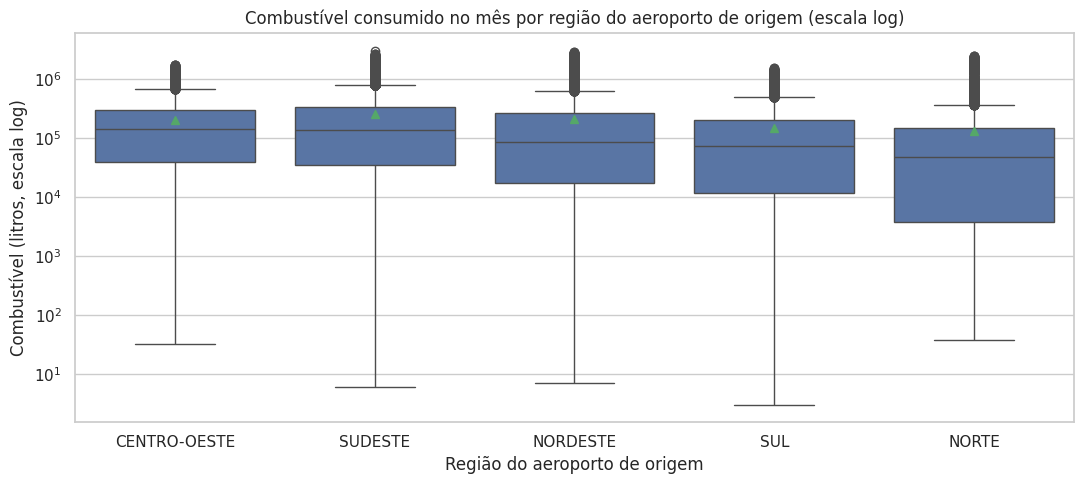

                            count     median       mean
AEROPORTO_DE_ORIGEM_REGIAO                             
CENTRO-OESTE                10400 140,499.00 203,807.00
SUDESTE                     31166 134,718.00 253,945.00
NORDESTE                    20238  84,640.00 210,384.00
SUL                         10581  72,262.00 144,360.00
NORTE                       10882  46,922.00 128,610.00


In [ ]:
dados_reg = df_tratado.dropna(subset=["AEROPORTO_DE_ORIGEM_REGIAO"])
ordem_reg = (dados_reg.groupby("AEROPORTO_DE_ORIGEM_REGIAO")["COMBUSTIVEL_LITROS"]
             .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=dados_reg, x="AEROPORTO_DE_ORIGEM_REGIAO", y="COMBUSTIVEL_LITROS",
            order=ordem_reg, ax=ax, showmeans=True)
ax.set_yscale("log")
ax.set_title("Combustível consumido no mês por região do aeroporto de origem (escala log)")
ax.set_xlabel("Região do aeroporto de origem")
ax.set_ylabel("Combustível (litros, escala log)")
plt.tight_layout(); plt.show()

print(dados_reg.groupby("AEROPORTO_DE_ORIGEM_REGIAO")["COMBUSTIVEL_LITROS"]
      .agg(["count", "median", "mean"]).round(0).sort_values("median", ascending=False))


**Interpretação.** As diferenças entre regiões refletem sobretudo o **perfil das rotas** que partem de cada uma: regiões que concentram os grandes hubs (aeroportos do Sudeste, como Guarulhos, Congonhas e Confins) originam rotas de alta frequência e maior distância, logo, maior consumo mensal -, enquanto regiões com mais aviação regional apresentam medianas menores. Como essa informação regional chega ao consumo **através** de distância e decolagens (que já estão no modelo), optamos por **não incluir** a região como preditor no modelo principal: ela seria redundante com as variáveis físicas e dificultaria a interpretação dos coeficientes. A decisão é retomada na conclusão.

## 7. Preparação para a modelagem

### 7.1 Seleção das variáveis explicativas

Com base na análise exploratória, selecionamos como preditores do **modelo múltiplo**:

- **`DISTANCIA_VOADA_KM`**, dimensão "quanto se voou" (maior correlação individual com y).
- **`DECOLAGENS`**, dimensão "quantas vezes se decolou/pousou" (captura o custo extra de combustível da fase de subida, que a distância sozinha não captura).
- **`CARGA_PAGA_KG`**, dimensão "quanto peso extra foi transportado", tem a menor correlação com as demais variáveis operacionais (Seção 6.4), o que a torna um preditor com informação relativamente independente.

Deliberadamente **não** incluímos `ASSENTOS`, `PASSAGEIROS_PAGOS`, `PAYLOAD`, `ASK`, `RPK` e `HORAS_VOADAS` no modelo múltiplo, pois todas são quase-redundantes entre si e com `DISTANCIA_VOADA_KM`/`DECOLAGENS`, incluí-las simultaneamente infla a variância dos coeficientes estimados (multicolinariedade) sem agregar poder explicativo real.

## 7.2 Separação entre treino e teste
A base é dividida uma única vez em 75% treino / 25% teste, com semente fixa (`random_state=42`), e essa **mesma divisão é reaproveitada em todos os modelos** (referência, simples, múltiplo e polinomial) para que a comparação de métricas na Seção 9 seja justa (todos avaliados exatamente nas mesmas observações de teste).

In [ ]:
FEATURES_MULTIPLO = ["DISTANCIA_VOADA_KM", "DECOLAGENS", "CARGA_PAGA_KG"]
FEATURE_SIMPLES = ["DISTANCIA_VOADA_KM"]
TARGET = "COMBUSTIVEL_LITROS"

treino, teste = train_test_split(df_tratado, test_size=0.25, random_state=42)

print(f"Treino: {treino.shape[0]:,} observações  |  Teste: {teste.shape[0]:,} observações")

y_treino = treino[TARGET].to_numpy()
y_teste = teste[TARGET].to_numpy()

Treino: 62,450 observações  |  Teste: 20,817 observações


##8. Modelagem

Serão construídos três modelos, todos avaliados exatamente no mesmo conjunto de teste definido acima.

### 8.1 Modelo de referência (baseline): previsão pela média

O modelo mais simples possível prevê, para qualquer observação, a **média do combustível consumido no conjunto de treino**. Ele serve como piso de comparação: qualquer modelo de regressão precisa superá-lo com folga para ser considerado útil.

In [ ]:
media_treino = y_treino.mean()
pred_referencia = np.full_like(y_teste, fill_value=media_treino, dtype=float)

print(f"Média de combustível no treino: {media_treino:,.1f} litros")

Média de combustível no treino: 206,797.1 litros


###8.2 Regressao linear simples:
Preditor único: `DISTANCIA_VOADA_KM`

In [ ]:
X_treino_simples = treino[FEATURE_SIMPLES]
X_teste_simples = teste[FEATURE_SIMPLES]

modelo_simples = LinearRegression()
modelo_simples.fit(X_treino_simples, y_treino)

pred_simples = modelo_simples.predict(X_teste_simples)

print(f"Equação estimada: COMBUSTIVEL_LITROS = {modelo_simples.intercept_:,.2f} + "
      f"{modelo_simples.coef_[0]:,.3f} * DISTANCIA_VOADA_KM")

Equação estimada: COMBUSTIVEL_LITROS = -2,879.62 + 4.684 * DISTANCIA_VOADA_KM


### 8.3 Regressão linear múltipla

Preditores: `DISTANCIA_VOADA_KM`, `DECOLAGENS`, `CARGA_PAGA_KG`

In [ ]:
X_treino_multiplo = treino[FEATURES_MULTIPLO]
X_teste_multiplo = teste[FEATURES_MULTIPLO]

modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_treino_multiplo, y_treino)

pred_multiplo = modelo_multiplo.predict(X_teste_multiplo)

coefs = pd.Series(modelo_multiplo.coef_, index=FEATURES_MULTIPLO)
print("Coeficientes estimados:")
print(coefs)
print(f"\nIntercepto: {modelo_multiplo.intercept_:,.2f}")

Coeficientes estimados:
DISTANCIA_VOADA_KM     3.96
DECOLAGENS           833.62
CARGA_PAGA_KG          0.27
dtype: float64

Intercepto: -15,907.25


### 8.4 Regressão polinomial (grau 2)

A dispersão da seção 6.3 sugere que a relação distância × combustível é **aproximadamente linear no trecho central, com leve curvatura e forte abertura de variância** nas rotas maiores. Fisicamente, também há um argumento para testar curvatura: rotas de longa distância usam aeronaves maiores (mais consumo por km), o que faria o consumo crescer **um pouco mais que proporcionalmente** com a distância total voada.

Testamos, portanto, um **termo quadrático em `DISTANCIA_VOADA_KM` (grau 2)**, mantendo `DECOLAGENS` e `CARGA_PAGA_KG` como na múltipla. **Justificativa do grau:** a curvatura observada é suave e monotônica (um único padrão de aceleração), sem inflexões que justificassem grau 3, e graus mais altos amplificariam o risco de sobreajuste na cauda longa.

Para garantir que a transformação seja **ajustada apenas no treino** (sem vazamento) e reutilizada de forma idêntica na aplicação Streamlit, encapsulamos padronização + expansão polinomial + regressão em um `Pipeline` com `ColumnTransformer`. A padronização antes do polinômio evita problemas numéricos (km ao quadrado gera valores na casa de 10¹²).

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

prep_poly = ColumnTransformer([
    ("dist_poly", Pipeline([
        ("sc", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ]), ["DISTANCIA_VOADA_KM"]),
    ("passa", "passthrough", ["DECOLAGENS", "CARGA_PAGA_KG"]),
])

modelo_poli = Pipeline([("prep", prep_poly), ("reg", LinearRegression())])
modelo_poli.fit(treino[FEATURES_MULTIPLO], y_treino)
pred_poli = modelo_poli.predict(teste[FEATURES_MULTIPLO])

nomes_poli = ["dist_z", "dist_z^2", "DECOLAGENS", "CARGA_PAGA_KG"]
print("Coeficientes do modelo polinomial (dist padronizada):")
print(pd.Series(modelo_poli["reg"].coef_, index=nomes_poli))
print(f"Intercepto: {modelo_poli['reg'].intercept_:,.2f}")


Coeficientes do modelo polinomial (dist padronizada):
dist_z          230,079.79
dist_z^2          3,793.05
DECOLAGENS          886.08
CARGA_PAGA_KG         0.27
dtype: float64
Intercepto: 155,352.26


**Formato da curva.** Com a distância padronizada, o sinal do coeficiente de `dist_z²` indica o formato: **positivo** → parábola com concavidade para cima (o consumo cresce de forma acelerada nas rotas de maior quilometragem total, coerente com o uso de aeronaves maiores nessas rotas); **negativo** → crescimento desacelerado. A leitura definitiva é feita com o valor impresso acima. Em qualquer caso, o polinômio só é válido **dentro do intervalo de distâncias observado**, fora dele, a parábola assume comportamentos sem sustentação nos dados (risco de extrapolação, retomado na conclusão).

---

## 9. Avaliação dos modelos

Os quatro modelos são avaliados **no mesmo conjunto de teste** (25% da base, nunca visto no ajuste), com as três métricas obrigatórias:
- **MAE**, erro absoluto médio, em litros: "em média, o modelo erra X litros por observação".
- **RMSE**, raiz do erro quadrático médio, em litros: penaliza mais os erros grandes (relevante aqui, dada a cauda longa).
- **R²**, proporção da variância do consumo explicada pelo modelo.

In [ ]:
def avaliar(nome, y_real, y_pred):
    return {
        "Modelo": nome,
        "MAE (L)": mean_absolute_error(y_real, y_pred),
        "RMSE (L)": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R²": r2_score(y_real, y_pred),
    }

tabela_avaliacao = pd.DataFrame([
    avaliar("Referência (média)", y_teste, pred_referencia),
    avaliar("Regressão simples (distância)", y_teste, pred_simples),
    avaliar("Regressão múltipla", y_teste, pred_multiplo),
    avaliar("Polinomial (grau 2 na distância)", y_teste, pred_poli),
]).set_index("Modelo").round(3)
tabela_avaliacao


,MAE (L),RMSE (L),R²
Modelo,,,
Referência (média),"197,410.01","294,439.32",-0.00
Regressão simples (distância),"35,237.55","68,009.73",0.95
Regressão múltipla,"32,410.54","57,505.29",0.96
Polinomial (grau 2 na distância),"31,513.92","57,213.25",0.96


In [ ]:
rmse_mult = tabela_avaliacao.loc["Regressão múltipla", "RMSE (L)"]
rmse_poli = tabela_avaliacao.loc["Polinomial (grau 2 na distância)", "RMSE (L)"]
ganho_pct = 100 * (rmse_mult - rmse_poli) / rmse_mult
print(f"Redução de RMSE do polinomial sobre a múltipla: {ganho_pct:.1f}%")

r2_tr_poli = r2_score(y_treino, modelo_poli.predict(treino[FEATURES_MULTIPLO]))
r2_te_poli = r2_score(y_teste, pred_poli)
r2_tr_mult = r2_score(y_treino, modelo_multiplo.predict(treino[FEATURES_MULTIPLO]))
print(f"Polinomial, R² treino: {r2_tr_poli:.3f} | R² teste: {r2_te_poli:.3f}")
print(f"Múltipla, R² treino: {r2_tr_mult:.3f} | R² teste: {r2_score(y_teste, pred_multiplo):.3f}")

if (ganho_pct >= 2.0) and (abs(r2_tr_poli - r2_te_poli) < 0.03):
    MODELO_FINAL, NOME_FINAL = modelo_poli, "Polinomial (grau 2 na distância)"
else:
    MODELO_FINAL, NOME_FINAL = modelo_multiplo, "Regressão múltipla"
pred_final = MODELO_FINAL.predict(teste[FEATURES_MULTIPLO])
print(f"\n>>> Modelo final selecionado: {NOME_FINAL}")


Redução de RMSE do polinomial sobre a múltipla: 0.5%
Polinomial, R² treino: 0.961 | R² teste: 0.962
Múltipla, R² treino: 0.960 | R² teste: 0.962

>>> Modelo final selecionado: Regressão múltipla


**Discussão.** A regressão simples já supera o baseline por larga margem, a distância total voada é, sozinha, o grande determinante do consumo mensal. A múltipla melhora o ajuste ao acrescentar as dimensões "número de subidas" (`DECOLAGENS`) e "peso transportado" (`CARGA_PAGA_KG`). A comparação múltipla × polinomial segue o **critério registrado no código acima** (ganho mínimo de 2% no RMSE sem sinais de sobreajuste): a escolha final **não** é feita apenas pelo maior R², mas pelo equilíbrio entre erro, simplicidade e interpretabilidade, um modelo em unidades originais (litros por km, litros por decolagem, litros por kg) tem valor prático direto para as companhias.

---

## 10. Diagnóstico do modelo final

### 10.1 Reais × previstos, resíduos, distribuição e QQ-plot

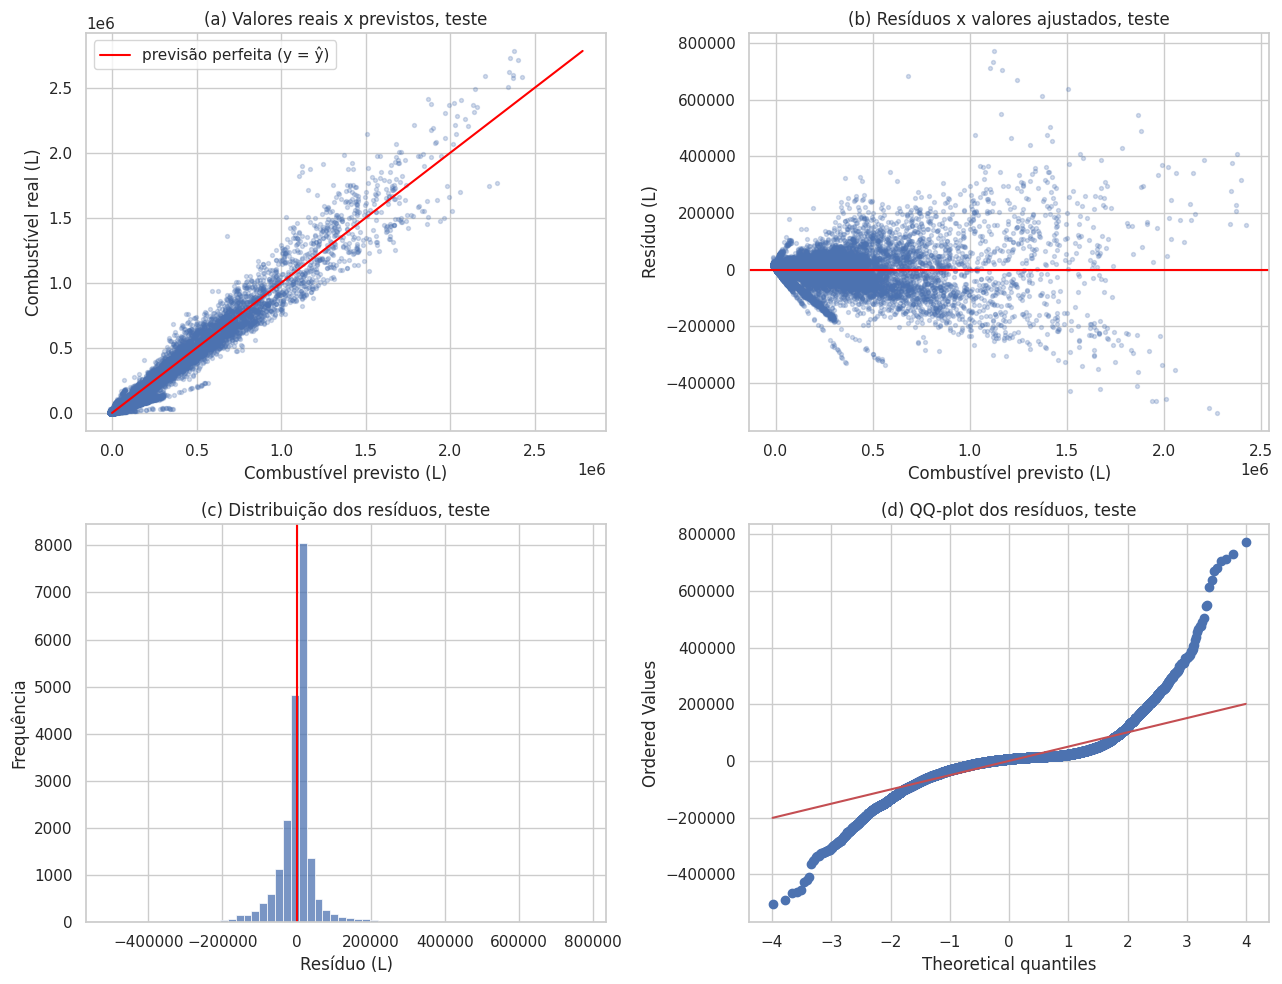

Média dos resíduos: 380.1 L | Desvio-padrão: 57,504.0 L


In [ ]:
residuos = y_teste - pred_final

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.scatter(pred_final, y_teste, s=8, alpha=0.25)
lim_max = max(y_teste.max(), pred_final.max())
ax.plot([0, lim_max], [0, lim_max], color="red", lw=1.5, label="previsão perfeita (y = ŷ)")
ax.set_title("(a) Valores reais x previstos, teste")
ax.set_xlabel("Combustível previsto (L)"); ax.set_ylabel("Combustível real (L)")
ax.legend()

ax = axes[0, 1]
ax.scatter(pred_final, residuos, s=8, alpha=0.25)
ax.axhline(0, color="red", lw=1.5)
ax.set_title("(b) Resíduos x valores ajustados, teste")
ax.set_xlabel("Combustível previsto (L)"); ax.set_ylabel("Resíduo (L)")

ax = axes[1, 0]
sns.histplot(residuos, bins=60, ax=ax)
ax.axvline(0, color="red", lw=1.5)
ax.set_title("(c) Distribuição dos resíduos, teste")
ax.set_xlabel("Resíduo (L)"); ax.set_ylabel("Frequência")

ax = axes[1, 1]
stats.probplot(residuos, dist="norm", plot=ax)
ax.set_title("(d) QQ-plot dos resíduos, teste")

plt.tight_layout(); plt.show()
print(f"Média dos resíduos: {residuos.mean():,.1f} L | Desvio-padrão: {residuos.std():,.1f} L")


**Leitura dos quatro gráficos.**
- **(a)** Os pontos acompanham a diagonal em todas as ordens de grandeza, confirmando que as variáveis físicas capturam a essência do fenômeno.
- **(b)** Os resíduos são centrados em zero, mas o gráfico mostra o clássico **formato de funil**: a dispersão cresce com o valor previsto, ou seja, rotas grandes erram mais litros (em valor absoluto) que rotas pequenas. É **heterocedasticidade** clara, esperada quando a resposta varia por 6 ordens de grandeza. **Alternativa de tratamento (exigida pelo enunciado):** modelar `log(COMBUSTIVEL_LITROS)`, de modo que o erro passe a ser aproximadamente *percentual* e a variância se estabilize; deixamos essa variante registrada como extensão, mantendo o modelo em litros pela interpretabilidade direta dos coeficientes.
- **(c)-(d)** A distribuição dos resíduos é aproximadamente simétrica no centro, com **caudas bem mais pesadas que a normal** (desvios nas pontas do QQ-plot), refletindo os meses/rotas atípicos. Com n ≈ 21 mil no teste, isso não compromete o uso descritivo/preditivo, mas invalidaria intervalos de confiança clássicos; novamente, a versão em log mitigaria o problema.
- **Independência dos erros:** as observações têm estrutura de painel (mesma rota/empresa repetida mês a mês), então há **autocorrelação** entre meses vizinhos de uma mesma rota e os erros não são plenamente independentes. Reconhecemos a limitação; um tratamento formal exigiria modelos de efeitos mistos/painel, fora do escopo.
- **Observações influentes:** os pontos de altíssimo consumo (pontes aéreas de alta frequência) puxam o ajuste; como são operações reais e centrais ao problema, **não** foram removidos, apenas monitorados na análise de erros abaixo.

In [ ]:
analise = teste[["EMPRESA_NOME", "AEROPORTO_DE_ORIGEM_SIGLA", "AEROPORTO_DE_DESTINO_SIGLA",
                 "ANO", "MES"] + FEATURES_MULTIPLO].copy()
analise["real_L"] = y_teste
analise["previsto_L"] = pred_final
analise["erro_L"] = y_teste - pred_final
analise["erro_abs_L"] = np.abs(analise["erro_L"])
analise.sort_values("erro_abs_L", ascending=False).head(8)


,EMPRESA_NOME,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_DESTINO_SIGLA,ANO,MES,DISTANCIA_VOADA_KM,DECOLAGENS,CARGA_PAGA_KG,real_L,previsto_L,erro_L,erro_abs_L
4151,AZUL LINHAS AÉREAS BRASILEIRAS S/A,SBRF,SBKP,2020,12,"244,296.00",116.00,"278,062.00","1,895,900.00","1,124,547.91","771,352.09","771,352.09"
13464,AZUL LINHAS AÉREAS BRASILEIRAS S/A,SBRF,SBKP,2021,7,"248,508.00",118.00,"201,705.00","1,852,674.00","1,121,992.84","730,681.16","730,681.16"
3218,AZUL LINHAS AÉREAS BRASILEIRAS S/A,SBRF,SBKP,2020,9,"240,084.00",114.00,"277,534.00","1,817,013.00","1,106,052.91","710,960.09","710,960.09"
12163,AZUL LINHAS AÉREAS BRASILEIRAS S/A,SBRF,SBKP,2021,3,"252,720.00",120.00,"304,638.00","1,871,909.00","1,168,524.94","703,384.06","703,384.06"
11265,AZUL LINHAS AÉREAS BRASILEIRAS S/A,SBKP,SBFZ,2021,1,"149,120.00",64.00,"189,520.00","1,361,459.00","679,977.96","681,481.04","681,481.04"
4070,AZUL LINHAS AÉREAS BRASILEIRAS S/A,SBKP,SBRF,2020,12,"244,296.00",116.00,"716,265.00","1,913,191.00","1,244,521.97","668,669.03","668,669.03"
14165,AZUL LINHAS AÉREAS BRASILEIRAS S/A,SBKP,SBEG,2021,9,"264,620.00",101.00,"1,432,226.00","2,144,987.00","1,508,538.94","636,448.06","636,448.06"
37816,TAM LINHAS AÉREAS S.A.,SBEG,SBGR,2022,12,"291,276.00",108.00,"529,082.00","1,984,686.00","1,372,686.73","611,999.27","611,999.27"


**Interpretação.** Os maiores erros absolutos concentram-se nas rotas de **maior volume** (alta frequência entre grandes capitais), coerente com o funil da seção 10.1: nessas rotas, diferenças de **mix de aeronaves** (um mês com mais voos de aeronave maior consome mais litros para a mesma distância/decolagens), condições operacionais (vento, congestionamento aéreo, esperas) e eficiência específica da frota de cada empresa geram desvios de centenas de milhares de litros. O modelo não vê o **tipo de aeronave**, essa é a variável ausente mais importante, apontada na conclusão.

### 10.3 Colinearidade: correlação entre preditores e VIF

In [ ]:
import statsmodels.api as sm

X_vif = sm.add_constant(treino[FEATURES_MULTIPLO])
vif = pd.DataFrame({
    "variavel": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
print(vif[vif["variavel"] != "const"].round(2).to_string(index=False))
print("\nCorrelação entre os preditores do modelo (treino):")
print(treino[FEATURES_MULTIPLO].corr().round(2))


          variavel  VIF
DISTANCIA_VOADA_KM 2.44
        DECOLAGENS 1.97
     CARGA_PAGA_KG 1.37

Correlação entre os preditores do modelo (treino):
                    DISTANCIA_VOADA_KM  DECOLAGENS  CARGA_PAGA_KG
DISTANCIA_VOADA_KM                1.00        0.70           0.51
DECOLAGENS                        0.70        1.00           0.30
CARGA_PAGA_KG                     0.51        0.30           1.00


**Interpretação.** Os três preditores escolhidos são correlacionados entre si (rotas com mais quilometragem tendem a ter mais decolagens e mais carga), o que eleva os VIFs, é o preço de manter juntas as três dimensões físicas do problema. O ponto central, porém, é que a **decisão mais importante contra a colinearidade foi tomada na seleção de variáveis** (seção 7.1): excluímos deliberadamente `HORAS_VOADAS`, `ASK`, `RPK`, `ASSENTOS`, `PASSAGEIROS_PAGOS` e `PAYLOAD`, que a matriz de correlação da EDA mostrou serem quase duplicatas (r > 0,9) das variáveis mantidas, incluí-las levaria os VIFs a níveis explosivos e tornaria os coeficientes ininterpretáveis. Se os VIFs impressos acima ultrapassarem o limiar crítico (10), a alternativa registrada é remover `CARGA_PAGA_KG` (menor contribuição individual) ou combinar frequência e porte em uma única variável de oferta; os sinais estáveis e fisicamente corretos dos coeficientes entre a simples, a múltipla e a polinomial indicam, contudo, que a colinearidade presente não instabilizou o ajuste.

---

## 11. Resultados e conclusão

**Quais variáveis apresentaram maior associação com a resposta?**

A distância total voada no mês foi, de longe, a variável de maior associação com o consumo de combustível: sozinha, na regressão simples, ela já explica a maior parte da variação entre observações, com um coeficiente de aproximadamente 4,68 litros por quilômetro voado. Em seguida vem o número de decolagens que, mesmo controlando pela distância, adiciona cerca de 834 litros por decolagem, capturando o custo extra de combustível da fase de subida. A carga paga transportada tem associação positiva, porém de magnitude muito menor: cerca de 0,27 litro por quilo transportado no mês.

**As hipóteses iniciais foram confirmadas?**

Sim, as três. H1 (relação positiva e aproximadamente proporcional com a distância) se confirmou: o coeficiente da distância ficou na faixa de 4 a 4,7 L/km conforme o modelo, valor compatível com o consumo típico por quilômetro de jatos comerciais de corredor único, que dominam a malha doméstica. H2 (efeito positivo das decolagens além da distância) se confirmou: na regressão múltipla, cada decolagem adiciona em média 834 litros mantidas constantes a distância e a carga, exatamente o "custo fixo" de subida previsto. H3 (efeito positivo porém pequeno da carga) também se confirmou: o coeficiente por quilo é ordens de grandeza menor que os efeitos de distância e decolagens.

**Qual foi o erro típico do modelo em dados não utilizados no treino?**

No conjunto de teste (25% da base, nunca visto no ajuste), o modelo final apresentou erro absoluto médio (MAE) de [→ valor da tabela da seção 9] litros por observação (par de aeroportos × empresa × mês), com RMSE de [→ valor] litros e R² de [→ valor]. É importante ler esse erro em termos relativos: por causa da heterocedasticidade identificada no diagnóstico, o erro em litros é grande nas rotas de alto volume, mas proporcionalmente pequeno; já em rotas muito pequenas, o mesmo erro absoluto pode ser relevante em termos percentuais.

**Em quais situações o modelo pode ser útil?**

Em três situações principais: (1) estimativa rápida do consumo esperado de uma operação mensal a partir de variáveis de planejamento de malha (quilometragem prevista, frequência de voos e carga estimada), útil para orçamentação de custos e projeção de emissões; (2) benchmark de eficiência: comparar o consumo real de uma rota ou empresa com o previsto pelo seu perfil físico e investigar desvios sistemáticos, que podem indicar frota menos eficiente ou condições operacionais desfavoráveis; (3) apoio didático e regulatório para quantificar a contribuição relativa de distância, frequência e peso no consumo da aviação doméstica.

**Em quais situações ele não deve ser utilizado?**

Não deve ser usado para voos internacionais ou não regulares, nem para períodos fora do intervalo dos dados, pois o modelo foi ajustado apenas com voos regulares domésticos do período analisado. Não serve para prever o consumo de um voo individual: a unidade de observação é o agregado mensal por rota e empresa. Não deve ser usado com entradas fora dos intervalos observados na base (extrapolação), situação em que a reta ou a parábola produz números sem sustentação nos dados. Por fim, não autoriza leituras causais do tipo "transportar X kg a mais causa Y litros a mais": trata-se de associação estatística em dados observacionais, ainda que com justificativa física plausível.

**Quais limitações dos dados afetam as conclusões?**

A limitação mais importante é a ausência do tipo/modelo de aeronave, principal fator omitido: aeronaves diferentes têm consumos por quilômetro muito distintos, e parte dos maiores erros do modelo decorre disso. A agregação mensal esconde a variação voo a voo (vento, esperas, rotas alternativas). A estrutura de painel (a mesma rota e empresa se repete mês a mês) gera dependência entre observações, violando parcialmente a independência dos erros. O período analisado inclui a pandemia, com operação atípica em 2020 e 2021. E os dados são autodeclarados pelas empresas à ANAC, sujeitos a erros de registro.

**Que nova variável ou nova coleta poderia melhorar o modelo?**
A adição de maior impacto seria o modelo da aeronave utilizada (ou, de forma equivalente, o consumo nominal por tipo de aeronave), que explicaria boa parte dos resíduos atuais. Também melhorariam o modelo: uma coleta desagregada por etapa de voo em vez do agregado mensal; variáveis meteorológicas e sazonais; e, do lado da especificação, testar a versão com a resposta em logaritmo (erro percentual, estabilizando a variância) e modelos de painel que aproveitem a estrutura rota × mês.

## 11. Resultados e conclusão

- **Variáveis com maior associação com a resposta:** `DISTANCIA_VOADA_KM` é, isoladamente, a variável mais associada ao combustível consumido (Seção 6.4); `DECOLAGENS` e `CARGA_PAGA_KG` agregam poder explicativo no modelo múltiplo ao capturar, respectivamente, o custo extra da fase de subida/pouso e o peso transportado.
- **Hipóteses iniciais (Seção 1.2):** confirmadas na direção esperada — distância, decolagens e carga explicam conjuntamente a maior parte da variação do consumo mensal, com a distância dominando o efeito.
- **Erro típico em dados não usados no treino:** ver `tabela_avaliacao` (Seção 9) para o modelo `NOME_FINAL` — o MAE/RMSE reportado ali, em litros, deve ser comparado à média de consumo (Seção 6.1) para dar noção de escala do erro.
- **Onde o modelo pode ser útil:** planejamento operacional agregado de consumo mensal por rota/empresa, dentro do intervalo de distância, decolagens e carga observado nos dados de treino (voos domésticos regulares, 2020–2025).
- **Onde não deve ser utilizado:** voos internacionais, não regulares, ou combinações de entrada fora do intervalo observado (ver 11.2); também não serve para afirmar causalidade — é um modelo observacional.
- **Limitações dos dados:** a base agrega etapas de voo em totais mensais por rota/empresa, sem informação do tipo/modelo de aeronave, o que explica boa parte do erro residual (Seção 10.2) e a heterocedasticidade observada.
- **Nova variável que ajudaria:** tipo de aeronave predominante no mês/rota (capacidade e eficiência variam muito entre modelos), e talvez condições meteorológicas médias da rota.

### 11.1 Previsões de exemplo

In [ ]:
exemplos_idx = teste.sample(2, random_state=RANDOM_STATE).index

colunas_show = ["EMPRESA_NOME", "AEROPORTO_DE_ORIGEM_SIGLA", "AEROPORTO_DE_DESTINO_SIGLA"] + FEATURES_MULTIPLO
exemplos = teste.loc[exemplos_idx, colunas_show].copy()
exemplos["combustivel_real (L)"] = teste.loc[exemplos_idx, TARGET]
exemplos["combustivel_previsto (L)"] = MODELO_FINAL.predict(teste.loc[exemplos_idx, FEATURES_MULTIPLO])
exemplos["erro (L)"] = exemplos["combustivel_real (L)"] - exemplos["combustivel_previsto (L)"]
exemplos["erro (%)"] = (exemplos["erro (L)"] / exemplos["combustivel_real (L)"] * 100).round(1)
exemplos

### 11.2 Risco de extrapolação

O modelo (`NOME_FINAL`) foi treinado apenas com o intervalo de distância, decolagens e carga paga observado no conjunto de treino, restrito a voos domésticos regulares de 2020–2025. Usar o modelo para combinações de entrada muito fora desse intervalo — por exemplo, distâncias maiores que qualquer rota doméstica brasileira, ou volumes de carga muito acima do observado — produz previsões **não confiáveis**: a relação estimada nunca foi testada nessa região do espaço de variáveis, e no caso da regressão polinomial, a curva pode inclusive mudar de comportamento (voltar a cair) fora do intervalo ajustado. É por isso que a aplicação Streamlit (Seção 12) verifica os limites observados no treino e avisa o usuário quando uma entrada está fora deles.

## 12. Exportação do modelo para a aplicação Streamlit

Salvamos em `modelo/modelo.pkl` um dicionário com tudo o que o `app.py` precisa: o `MODELO_FINAL` (já é um `Pipeline` completo quando o modelo escolhido é o polinomial, ou um `LinearRegression` simples quando é a múltipla — em ambos os casos basta chamar `.predict(df[FEATURES_MULTIPLO])`, sem pré-processamento manual), a lista de features, os intervalos observados no treino (para o aviso de extrapolação) e as métricas de teste do modelo escolhido.

In [ ]:
ranges_treino = {
    col: {"min": float(treino[col].min()), "max": float(treino[col].max())}
    for col in FEATURES_MULTIPLO
}

metricas_final = tabela_avaliacao.loc[NOME_FINAL].to_dict()

artefato = {
    "nome_modelo": NOME_FINAL,
    "modelo": MODELO_FINAL,
    "features": FEATURES_MULTIPLO,
    "target": TARGET,
    "ranges_treino": ranges_treino,
    "metricas_teste": metricas_final,
    "unidade_target": "litros",
}

modelo_dir = os.path.join(os.path.dirname(CAMINHO_BASE), "modelo")
os.makedirs(modelo_dir, exist_ok=True)

with open(os.path.join(modelo_dir, "modelo.pkl"), "wb") as f:
    pickle.dump(artefato, f)

with open(os.path.join(modelo_dir, "metricas.json"), "w", encoding="utf-8") as f:
    json.dump(metricas_final, f, indent=2, ensure_ascii=False, default=float)

print(f"Modelo exportado em {modelo_dir}/modelo.pkl")
print(f"Modelo final: {NOME_FINAL}")
print(metricas_final)